In [2]:
import os
import sys

REPO_ROOT = "/home/lucasthim/projects/phd/mmml-alzheimer-diagnosis"

# mri_train.py's own internal imports (`sys.path.append("./../models")` etc.) are CWD-relative,
# not __file__-relative -- CWD must be src/model_training/ for them to resolve.
os.chdir(REPO_ROOT)
sys.path.insert(0, os.getcwd())

import pandas as pd

print("CWD:", os.getcwd())

CWD: /home/lucasthim/projects/phd/mmml-alzheimer-diagnosis


In [3]:
df_processed_mris = pd.read_csv("data/reference/PROCESSED_MRI_REFERENCE_ALL_ORIENTATIONS_20260710_1413.csv")

In [ ]:
df_processed_mris.query("GROUP in ('CN','MCI')")

,SUBJECT,IMAGE_DATA_ID,ORIENTATION,SLICE,VALID_IMAGE,GROUP,MACRO_GROUP,SEX,AGE,IMAGE_PATH,ORIGINAL_IMAGE_PATH,DATASET
0,941_S_7051,I1553005,coronal,43,True,CN,CN,1.0,64.0,/home/lucasthim/projects/phd/mmml-alzheimer-di...,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,train
1,941_S_7051,I1553005,axial,23,True,CN,CN,1.0,64.0,/home/lucasthim/projects/phd/mmml-alzheimer-di...,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,train
2,941_S_7051,I1553005,sagittal,26,True,CN,CN,1.0,64.0,/home/lucasthim/projects/phd/mmml-alzheimer-di...,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,train
3,006_S_6651,I1575205,coronal,43,True,MCI,MCI,0.0,59.0,/home/lucasthim/projects/phd/mmml-alzheimer-di...,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,train
4,006_S_6651,I1575205,axial,23,True,MCI,MCI,0.0,59.0,/home/lucasthim/projects/phd/mmml-alzheimer-di...,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,train
...,...,...,...,...,...,...,...,...,...,...,...,...
43717,003_S_4350,I844711,axial,8,True,CN,CN,1.0,73.0,/home/lucasthim/projects/phd/mmml-alzheimer-di...,/mnt/d/lucas/Downloads/preprocessed/20260707/A...,train
43718,003_S_4350,I844711,sagittal,50,True,CN,CN,1.0,73.0,/home/lucasthim/projects/phd/mmml-alzheimer-di...,/mnt/d/lucas/Downloads/preprocessed/20260707/A...,train
43719,114_S_0173,I94615,coronal,70,True,CN,CN,1.0,74.0,/home/lucasthim/projects/phd/mmml-alzheimer-di...,/mnt/d/lucas/Downloads/preprocessed/20260707/A...,train
43720,114_S_0173,I94615,axial,8,False,CN,CN,1.0,74.0,NaN,/mnt/d/lucas/Downloads/preprocessed/20260707/A...,train


In [ ]:
df_processed_mris.query("GROUP in ('CN','MCI')").groupby(['GROUP','ORIENTATION','SLICE']).agg({'IMAGE_DATA_ID':'nunique'}).reset_index() #.pivot(index='SLICE',columns='ORIENTATION',values='IMAGE_DATA_ID').sort_index(ascending=False)

,GROUP,ORIENTATION,SLICE,IMAGE_DATA_ID
0,CN,axial,8,2988
1,CN,axial,23,2988
2,CN,coronal,43,2988
3,CN,coronal,70,2988
4,CN,sagittal,26,2988
5,CN,sagittal,50,2988
6,MCI,axial,8,2938
7,MCI,axial,23,2938
8,MCI,coronal,43,2938
9,MCI,coronal,70,2938


In [ ]:
df_processed_mris.query("GROUP in ('CN','MCI') and IMAGE_PATH != IMAGE_PATH").groupby(['GROUP','ORIENTATION','SLICE']).agg({'IMAGE_DATA_ID':'nunique'}).reset_index().sum() #.pivot(index='SLICE',columns='ORIENTATION',values='IMAGE_DATA_ID').sort_index(ascending=False)

GROUP                                       CNCNMCIMCIMCIMCIMCIMCI
ORIENTATION      axialaxialaxialaxialcoronalcoronalsagittalsagi...
SLICE                                                          251
IMAGE_DATA_ID                                                 1567
dtype: object

In [ ]:
df_processed_mris.query("IMAGE_PATH != IMAGE_PATH")

,SUBJECT,IMAGE_DATA_ID,ORIENTATION,SLICE,VALID_IMAGE,GROUP,MACRO_GROUP,SEX,AGE,IMAGE_PATH,ORIGINAL_IMAGE_PATH,DATASET
88,126_S_4891,I1343064,axial,23,False,AD,AD,1.0,60.0,NaN,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,train
103,021_S_6914,I10291851,axial,23,False,CN,CN,1.0,70.0,NaN,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,test
121,003_S_6307,I1205679,axial,23,False,CN,CN,1.0,76.0,NaN,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,validation
862,135_S_6509,I1195531,axial,23,False,CN,CN,1.0,65.0,NaN,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,validation
1264,012_S_6503,I1052046,axial,23,False,MCI,MCI,1.0,76.0,NaN,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,train
...,...,...,...,...,...,...,...,...,...,...,...,...
43666,027_S_0118,I96275,axial,8,False,CN,CN,1.0,81.0,NaN,/mnt/d/lucas/Downloads/preprocessed/20260707/A...,train
43681,114_S_0173,I88456,axial,8,False,CN,CN,1.0,74.0,NaN,/mnt/d/lucas/Downloads/preprocessed/20260707/A...,train
43687,114_S_0416,I369070,axial,8,False,CN,CN,0.0,76.0,NaN,/mnt/d/lucas/Downloads/preprocessed/20260707/A...,train
43705,051_S_1072,I121952,axial,8,False,MCI,MCI,0.0,59.0,NaN,/mnt/d/lucas/Downloads/preprocessed/20260707/A...,train


In [ ]:
df_processed_mris.query("IMAGE_PATH != IMAGE_PATH")['ORIGINAL_IMAGE_PATH'][:5].tolist()

['/mnt/d/lucas/Downloads/preprocessed/20260709/ADNI_126_S_4891_I1343064.nii.gz',
 '/mnt/d/lucas/Downloads/preprocessed/20260709/ADNI_021_S_6914_I10291851.nii.gz',
 '/mnt/d/lucas/Downloads/preprocessed/20260709/ADNI_003_S_6307_I1205679.nii.gz',
 '/mnt/d/lucas/Downloads/preprocessed/20260709/ADNI_135_S_6509_I1195531.nii.gz',
 '/mnt/d/lucas/Downloads/preprocessed/20260709/ADNI_012_S_6503_I1052046.nii.gz']

In [ ]:
df_downloaded_mris = pd.read_csv("data/reference/DOWNLOAD_RAW_MRI.csv")

In [ ]:
df_downloaded_mris

,SUBJECT,IMAGE_DATA_ID,IMAGE_NAME,FORMAT,N_FILES,PATH
0,002_S_0295,I118671,ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correctio...,nii,1,/mnt/d/lucas/Downloads/raw/ADNI/002_S_0295/MPR...
1,002_S_0295,I123685,ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correctio...,nii,1,/mnt/d/lucas/Downloads/raw/ADNI/002_S_0295/MPR...
2,002_S_0295,I150177,ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correctio...,nii,1,/mnt/d/lucas/Downloads/raw/ADNI/002_S_0295/MPR...
3,002_S_0295,I291867,ADNI_002_S_0295_MR_MT1__GradWarp__N3m_Br_20120...,nii,1,/mnt/d/lucas/Downloads/raw/ADNI/002_S_0295/MT1...
4,002_S_0413,I11128519,ADNI_002_S_0413_MR_Accelerated_Sagittal_MPRAGE...,dcm,208,/mnt/d/lucas/Downloads/raw/ADNI/002_S_0413/Acc...
...,...,...,...,...,...,...
7504,941_S_7074,I10283169,ADNI_941_S_7074_MR_Accelerated_Sagittal_MPRAGE...,dcm,208,/mnt/d/lucas/Downloads/raw/ADNI/941_S_7074/Acc...
7505,941_S_7074,I1588331,ADNI_941_S_7074_MR_Accelerated_Sagittal_MPRAGE...,dcm,208,/mnt/d/lucas/Downloads/raw/ADNI/941_S_7074/Acc...
7506,941_S_7085,I1600180,ADNI_941_S_7085_MR_Accelerated_Sagittal_MPRAGE...,dcm,208,/mnt/d/lucas/Downloads/raw/ADNI/941_S_7085/Acc...
7507,941_S_7087,I1591321,ADNI_941_S_7087_MR_Accelerated_Sagittal_MPRAGE...,dcm,208,/mnt/d/lucas/Downloads/raw/ADNI/941_S_7087/Acc...


In [ ]:
df_downloaded_mris.query("IMAGE_DATA_ID in ['I11128519', 'I1553005']")

,SUBJECT,IMAGE_DATA_ID,IMAGE_NAME,FORMAT,N_FILES,PATH
4,002_S_0413,I11128519,ADNI_002_S_0413_MR_Accelerated_Sagittal_MPRAGE...,dcm,208,/mnt/d/lucas/Downloads/raw/ADNI/002_S_0413/Acc...
7503,941_S_7051,I1553005,ADNI_941_S_7051_MR_Accelerated_Sagittal_MPRAGE...,dcm,208,/mnt/d/lucas/Downloads/raw/ADNI/941_S_7051/Acc...


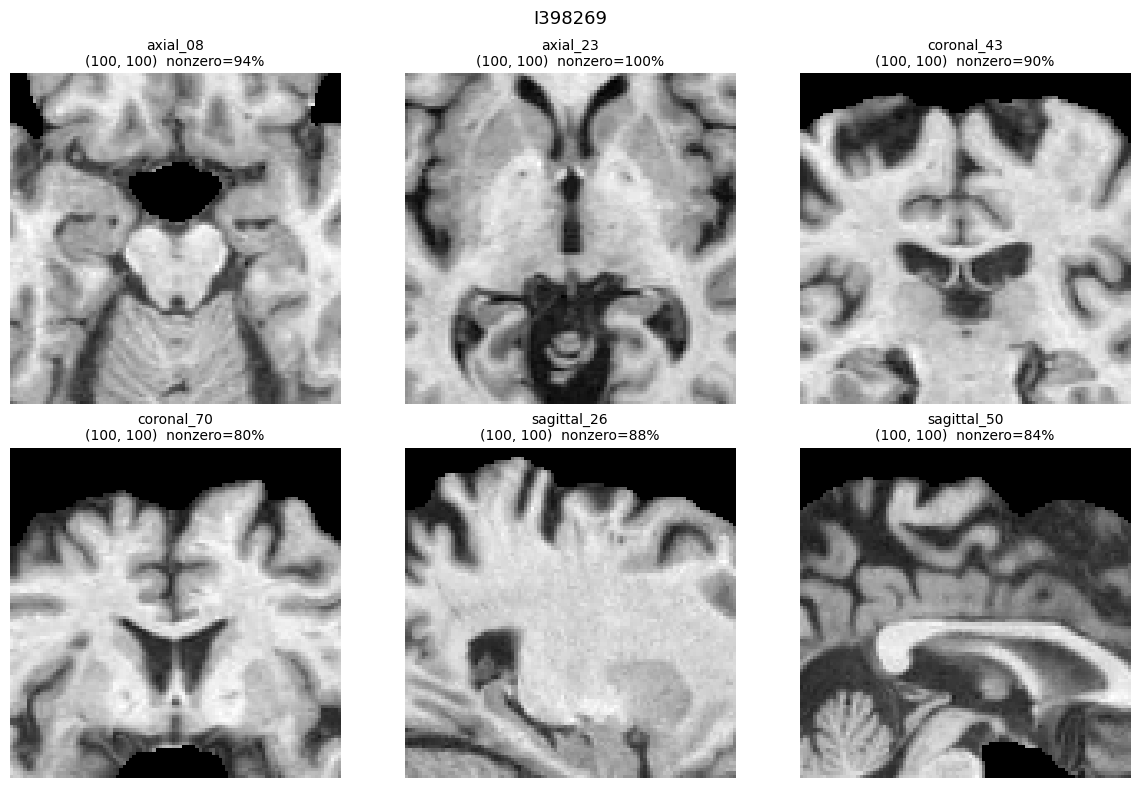

In [6]:
import glob, os
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = "/home/lucasthim/projects/phd/mmml-alzheimer-diagnosis"
STORAGE = os.path.join(REPO_ROOT, "data/mri/processed/storage")

def show_slices(image_id, cmap="gray"):
    """Display every .npz slice in an image's storage folder. image_id e.g. 'I1001084' or '1001084'."""
    image_id = image_id if str(image_id).startswith("I") else f"I{image_id}"
    folder = os.path.join(STORAGE, image_id)
    paths = sorted(glob.glob(os.path.join(folder, "*.npz")))
    if not paths:
        print(f"No slices found for {image_id} at {folder}")
        return

    n = len(paths)
    cols = min(n, 3)
    rows = -(-n // cols)  # ceil
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, p in zip(axes, paths):
        arr = np.load(p)["arr_0"]
        ax.imshow(arr, cmap=cmap)
        name = os.path.basename(p).replace(".npz", "")
        ax.set_title(f"{name}\n{arr.shape}  nonzero={ (arr>0).mean():.0%}", fontsize=10)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(image_id, fontsize=13)
    fig.tight_layout()
    plt.show()

# example
show_slices("I398269")